In [1]:
#all imports
import pandas as pd
import numpy as np 
import seaborn as sns 
from matplotlib import pyplot as plt
#scikit learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans

In [2]:
#read data
movies_analyze_df = pd.read_csv("tmdb_movies_data.csv")
#size before cleaning
movies_analyze_df.shape

(10866, 21)

In [3]:
#check data
movies_analyze_df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/2015,5562,6.5,2015,137999939.3,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/2015,6185,7.1,2015,137999939.3,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/2015,2480,6.3,2015,101199955.5,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/2015,5292,7.5,2015,183999919.0,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/2015,2947,7.3,2015,174799923.1,1.385749e+09


In [4]:
movies_analyze_df.dtypes

id                        int64
imdb_id                     str
popularity              float64
budget                    int64
revenue                   int64
original_title              str
cast                        str
homepage                    str
director                    str
tagline                     str
keywords                    str
overview                    str
runtime                   int64
genres                      str
production_companies        str
release_date                str
vote_count                int64
vote_average            float64
release_year              int64
budget_adj              float64
revenue_adj             float64
dtype: object

In [5]:
movies_analyze_df.isnull().sum()

id                         0
imdb_id                   10
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64

In [6]:
(movies_analyze_df == 0).sum()


id                         0
imdb_id                    0
popularity                 0
budget                  5696
revenue                 6016
original_title             0
cast                       0
homepage                   0
director                   0
tagline                    0
keywords                   0
overview                   0
runtime                   31
genres                     0
production_companies       0
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj              5696
revenue_adj             6016
dtype: int64

In [7]:
movies_analyze_df.columns

Index(['id', 'imdb_id', 'popularity', 'budget', 'revenue', 'original_title',
       'cast', 'homepage', 'director', 'tagline', 'keywords', 'overview',
       'runtime', 'genres', 'production_companies', 'release_date',
       'vote_count', 'vote_average', 'release_year', 'budget_adj',
       'revenue_adj'],
      dtype='str')

In [8]:
(movies_analyze_df == 0).sum()

id                         0
imdb_id                    0
popularity                 0
budget                  5696
revenue                 6016
original_title             0
cast                       0
homepage                   0
director                   0
tagline                    0
keywords                   0
overview                   0
runtime                   31
genres                     0
production_companies       0
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj              5696
revenue_adj             6016
dtype: int64

In [9]:
#drop columns
movies_analyze_df.drop(columns=["id","imdb_id","homepage","budget","revenue","original_title","director","tagline","overview","keywords","cast","production_companies", "genres"],inplace=True)
movies_analyze_df.shape

#drop rows w 0
movies_analyze_df = movies_analyze_df[
    (movies_analyze_df["budget_adj"] != 0) &
    (movies_analyze_df["revenue_adj"] != 0)
]

#rename colums
movies_analyze_df.rename(columns={"vote_count": "ratings_count"}, inplace=True)
movies_analyze_df.rename(columns={"vote_average": "ratings_avg"}, inplace=True)

In [10]:
(movies_analyze_df != 0).sum()

popularity       3855
runtime          3855
release_date     3855
ratings_count    3855
ratings_avg      3855
release_year     3855
budget_adj       3855
revenue_adj      3855
dtype: int64

In [11]:
movies_analyze_df.shape

(3855, 8)

In [12]:
movies_analyze_df.head()

,popularity,runtime,release_date,ratings_count,ratings_avg,release_year,budget_adj,revenue_adj
0,32.985763,124,6/9/2015,5562,6.5,2015,137999939.3,1.392446e+09
1,28.419936,120,5/13/2015,6185,7.1,2015,137999939.3,3.481613e+08
2,13.112507,119,3/18/2015,2480,6.3,2015,101199955.5,2.716190e+08
3,11.173104,136,12/15/2015,5292,7.5,2015,183999919.0,1.902723e+09
4,9.335014,137,4/1/2015,2947,7.3,2015,174799923.1,1.385749e+09


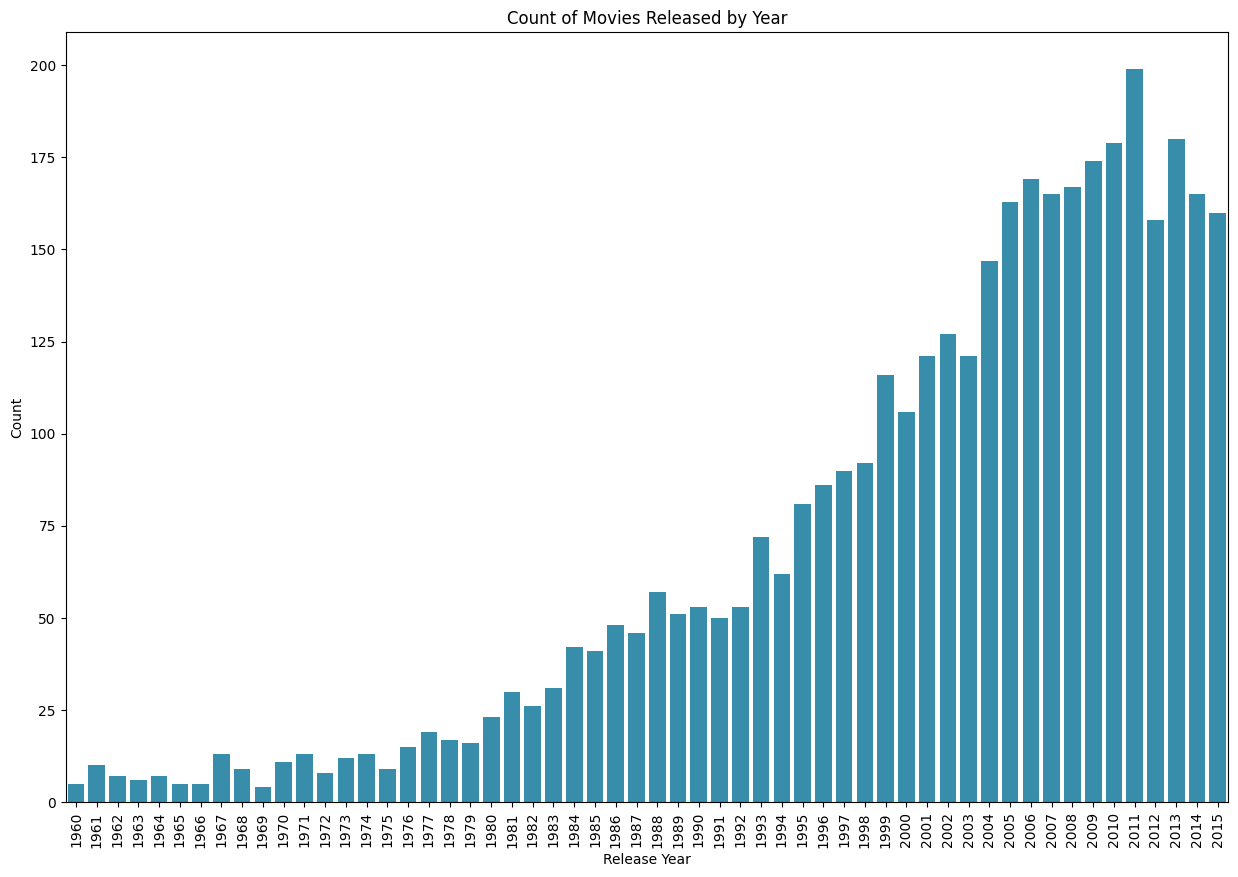

In [13]:
#movie released by year
plt.figure(figsize=(15,10))
sns.countplot(data=movies_analyze_df, x="release_year", color="#2596be")
plt.xticks(rotation=90)
plt.title("Count of Movies Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

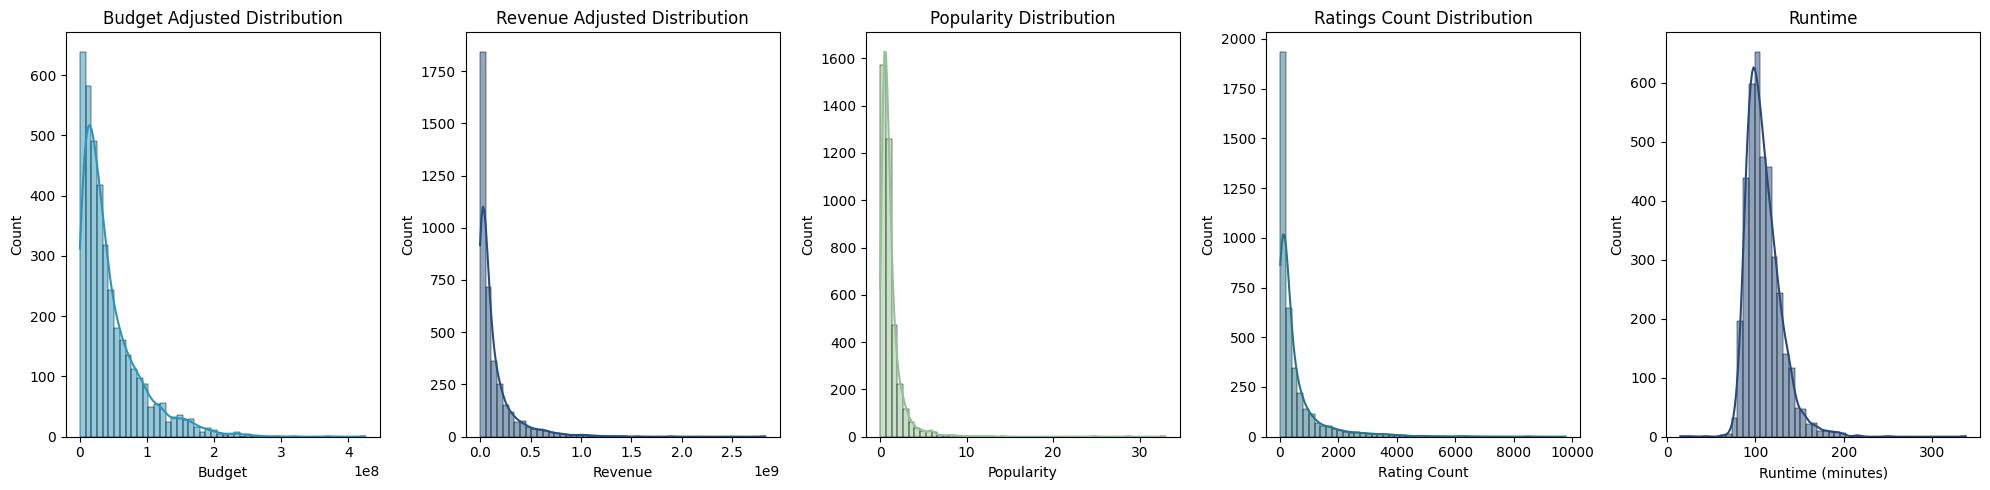

In [14]:

#Distributions for
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
#budget
sns.histplot(movies_analyze_df["budget_adj"], bins=50, kde=True, color="#2596be", ax=axes[0])
axes[0].set_title("Budget Adjusted Distribution")
axes[0].set_xlabel("Budget")
#revenue
sns.histplot(movies_analyze_df["revenue_adj"], bins=50, kde=True, color="#235082", ax=axes[1])
axes[1].set_title("Revenue Adjusted Distribution")
axes[1].set_xlabel("Revenue")
#popularity
sns.histplot(movies_analyze_df["popularity"], bins=50, kde=True, color="#92c392", ax=axes[2])
axes[2].set_title("Popularity Distribution")
axes[2].set_xlabel("Popularity")
#vote count
sns.histplot(movies_analyze_df["ratings_count"], bins=50, kde=True, color="#23758c", ax=axes[3])
axes[3].set_title("Ratings Count Distribution")
axes[3].set_xlabel("Rating Count")

sns.histplot(movies_analyze_df["runtime"], bins=50, kde=True, color="#244a7f", ax=axes[4])
axes[4].set_title("Runtime")
axes[4].set_xlabel("Runtime (minutes)")

plt.tight_layout()
plt.show()


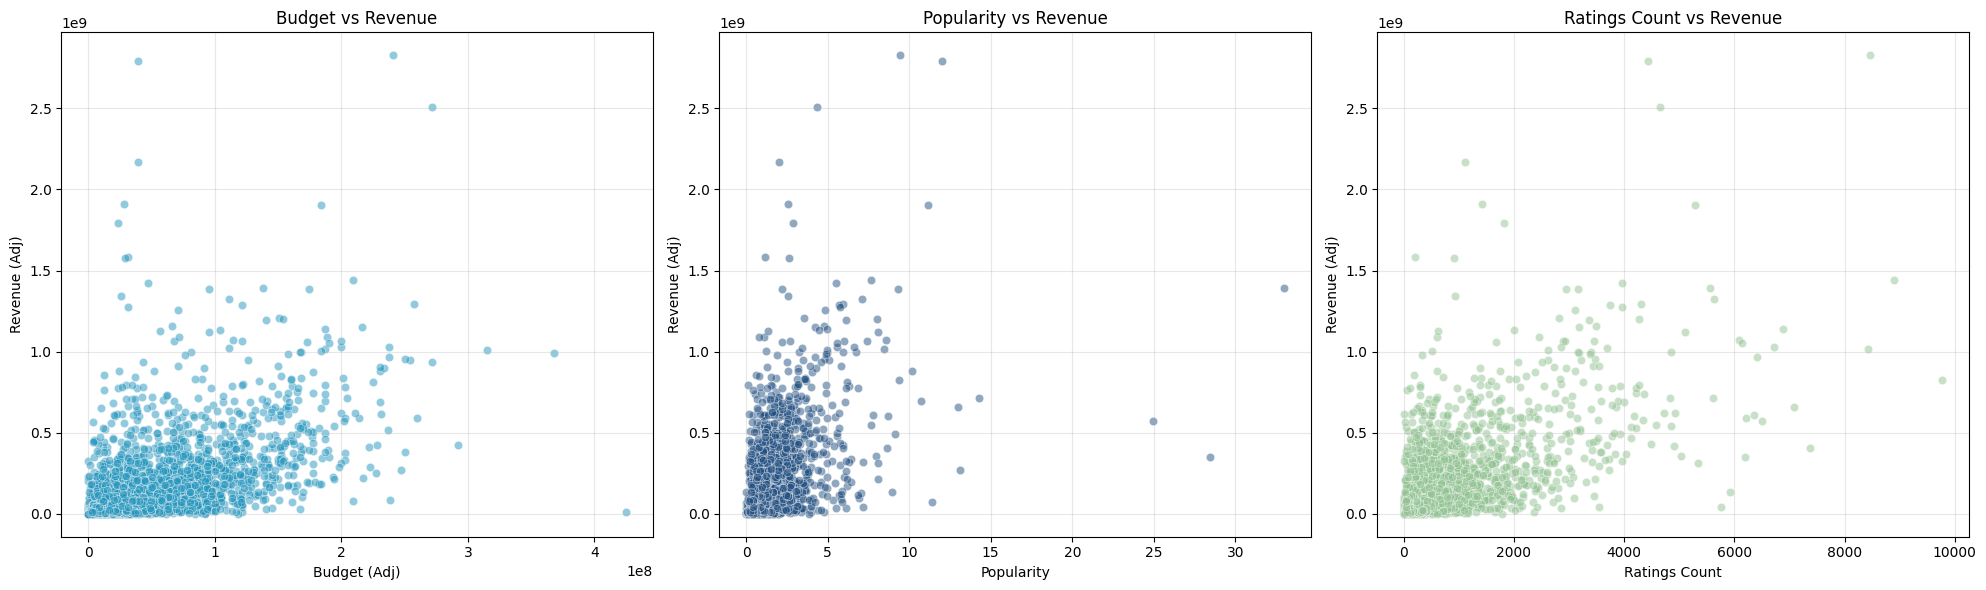

In [15]:
plt.figure(figsize=(20, 6))

# Budget vs Revenue
plt.subplot(1, 3, 1)
sns.scatterplot(data=movies_analyze_df, x="budget_adj", y="revenue_adj", alpha=0.5, color="#2596be")
plt.title("Budget vs Revenue")
plt.xlabel("Budget (Adj)")
plt.ylabel("Revenue (Adj)")
plt.grid(alpha=0.3)

# Popularity vs Revenue
plt.subplot(1, 3, 2)
sns.scatterplot(data=movies_analyze_df, x="popularity", y="revenue_adj", alpha=0.5, color="#235082")
plt.title("Popularity vs Revenue")
plt.xlabel("Popularity")
plt.ylabel("Revenue (Adj)")
plt.grid(alpha=0.3)

# Ratings Count vs Revenue
plt.subplot(1, 3, 3)
sns.scatterplot(data=movies_analyze_df, x="ratings_count", y="revenue_adj", alpha=0.5, color="#92c392")
plt.title("Ratings Count vs Revenue")
plt.xlabel("Ratings Count")
plt.ylabel("Revenue (Adj)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

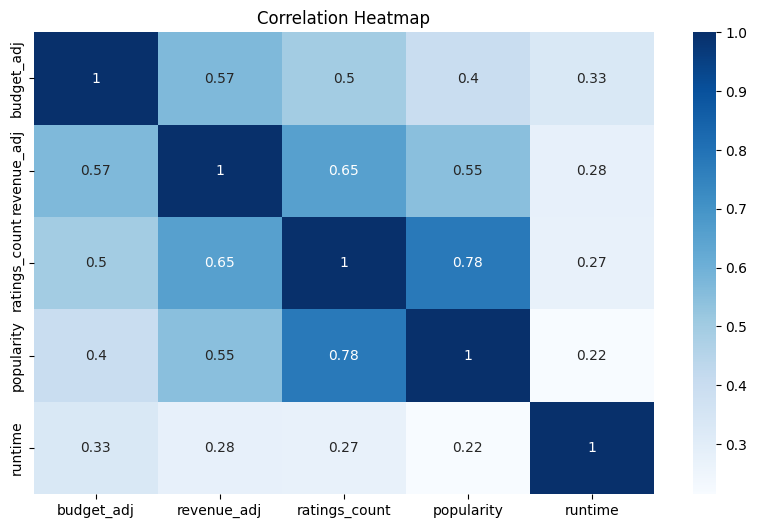

In [16]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    movies_analyze_df[["budget_adj","revenue_adj","ratings_count","popularity","runtime"]].corr(),
    annot=True,
    cmap="Blues"
)
plt.title("Correlation Heatmap")
plt.show()

In [22]:
#Logistic Regression
#make sucess variable
#if revenue is greater than budget the movie can be classified as success
movies_analyze_df["success"] = (movies_analyze_df["revenue_adj"] > movies_analyze_df["budget_adj"]).astype(int)

#pick feautures and target
features = ["budget_adj", "popularity", "ratings_count", "ratings_avg", "runtime"]
X = movies_analyze_df[features]
y = movies_analyze_df["success"]

#do train/test split - 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train logistic regression model
logisticregmodel = LogisticRegression(max_iter=1000)
logisticregmodel.fit(X_train_scaled, y_train)

# predictions
y_pred = logisticregmodel.predict(X_test_scaled)

# evaluate
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
print("Classification Report:", classification_report(y_test, y_pred))

Accuracy Score: 0.7574578469520103
Confusion Matrix: [[ 64 142]
 [ 45 520]]
Classification Report:               precision    recall  f1-score   support

           0       0.59      0.31      0.41       206
           1       0.79      0.92      0.85       565

    accuracy                           0.76       771
   macro avg       0.69      0.62      0.63       771
weighted avg       0.73      0.76      0.73       771



In [18]:
#KNN
#pick feautures and target
features = ["budget_adj", "popularity", "ratings_count", "ratings_avg", "runtime"]
X = movies_analyze_df[features]
y = movies_analyze_df["success"]

#do train/test split - 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train logistic regression model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# predictions
y_pred_knn = knn.predict(X_test_scaled)

# evaluate
print("Accuracy Score:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:", classification_report(y_test, y_pred_knn))

Accuracy Score: 0.7328145265888456
Confusion Matrix: [[ 80 126]
 [ 80 485]]
Classification Report:               precision    recall  f1-score   support

           0       0.50      0.39      0.44       206
           1       0.79      0.86      0.82       565

    accuracy                           0.73       771
   macro avg       0.65      0.62      0.63       771
weighted avg       0.72      0.73      0.72       771



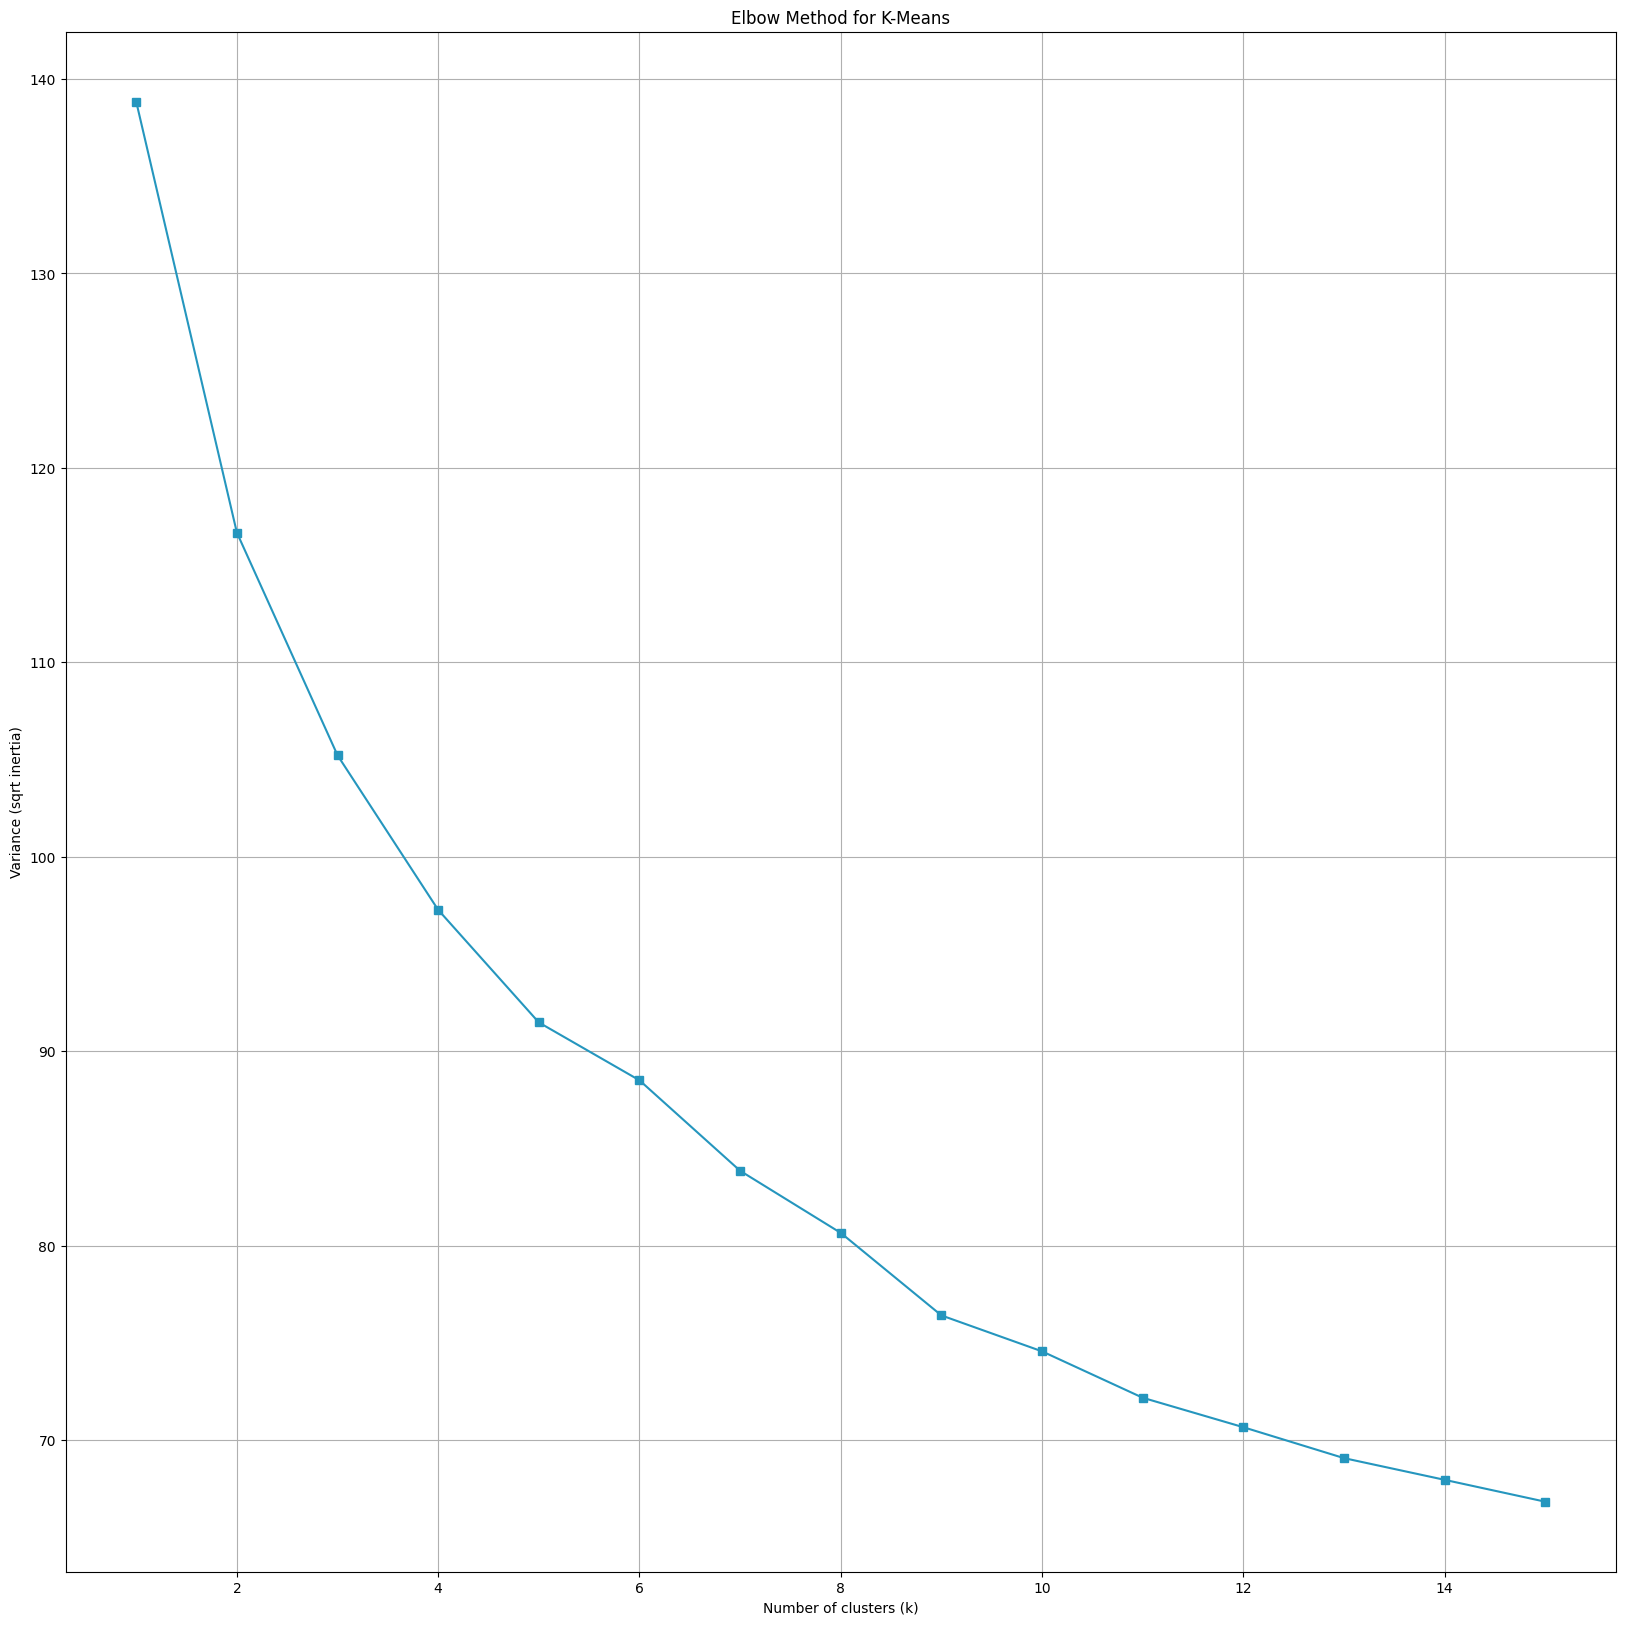

In [19]:
#KMeans
features = ["budget_adj", "popularity", "ratings_count", "ratings_avg", "runtime"]
Xkmeans = movies_analyze_df[features]

scaler = StandardScaler()
X_scaler = scaler.fit_transform(Xkmeans)

inertia = []

for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaler)
    inertia.append(np.sqrt(kmeans.inertia_))

plt.figure(figsize=(20, 20))
plt.plot(range(1, 16), inertia, marker='s', color='#2596be')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Variance (sqrt inertia)")
plt.title("Elbow Method for K-Means")
plt.grid(True)
plt.show()

In [20]:
# according to graph i think 3 is ideal because thats when it starts dropping more
#KMeans Continued
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X_scaler)

movies_analyze_df["cluster"] = kmeans.labels_

cluster_sizes = np.bincount(kmeans.labels_)
for i, size in enumerate(cluster_sizes):
    print(f"Cluster {i}: {size} movies")

Cluster 0: 1453 movies
Cluster 1: 2194 movies
Cluster 2: 208 movies


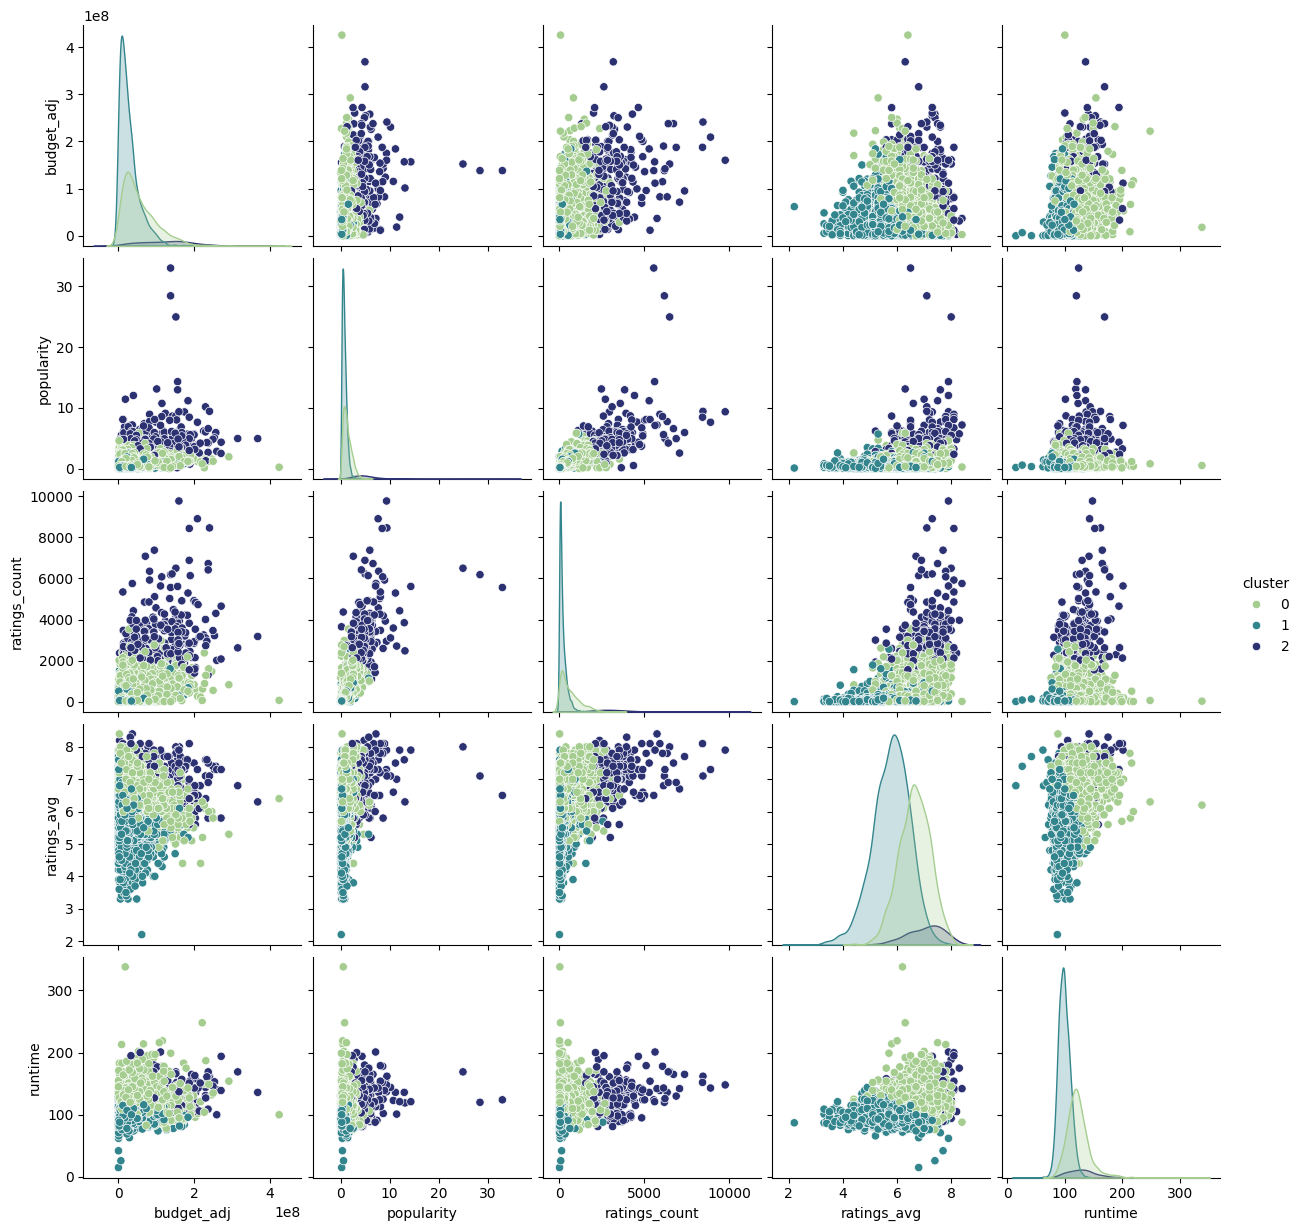

In [21]:
sns.pairplot(
    movies_analyze_df,
    vars=["budget_adj", "popularity", "ratings_count", "ratings_avg", "runtime"],
    hue="cluster",
    palette="crest",
    diag_kind="kde"
)
plt.show()